In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv("/content/Walmart.csv")

In [ ]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [ ]:
df.info

<bound method DataFrame.info of       Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1  05-02-2010    1643690.90             0        42.31       2.572   
1         1  12-02-2010    1641957.44             1        38.51       2.548   
2         1  19-02-2010    1611968.17             0        39.93       2.514   
3         1  26-02-2010    1409727.59             0        46.63       2.561   
4         1  05-03-2010    1554806.68             0        46.50       2.625   
...     ...         ...           ...           ...          ...         ...   
6430     45  28-09-2012     713173.95             0        64.88       3.997   
6431     45  05-10-2012     733455.07             0        64.89       3.985   
6432     45  12-10-2012     734464.36             0        54.47       4.000   
6433     45  19-10-2012     718125.53             0        56.47       3.969   
6434     45  26-10-2012     760281.43             0        58.85       3.882   

             CPI  Unemployment  
0     211.096358         8.106  
1     211.242170         8.106  
2     211.289143         8.106  
3     211.319643         8.106  
4     211.350143         8.106  
...          ...           ...  
6430  192.013558         8.684  
6431  192.170412         8.667  
6432  192.327265         8.667  
6433  192.330854         8.667  
6434  192.308899         8.667  

[6435 rows x 8 columns]>

In [ ]:
df.isna().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [ ]:
print(df.head())

   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90             0        42.31       2.572   
1      1 2010-02-12    1641957.44             1        38.51       2.548   
2      1 2010-02-19    1611968.17             0        39.93       2.514   
3      1 2010-02-26    1409727.59             0        46.63       2.561   
4      1 2010-03-05    1554806.68             0        46.50       2.625   

          CPI  Unemployment  Year  Month  
0  211.096358         8.106  2010      2  
1  211.242170         8.106  2010      2  
2  211.289143         8.106  2010      2  
3  211.319643         8.106  2010      2  
4  211.350143         8.106  2010      3  


# مبيعات كل سنه




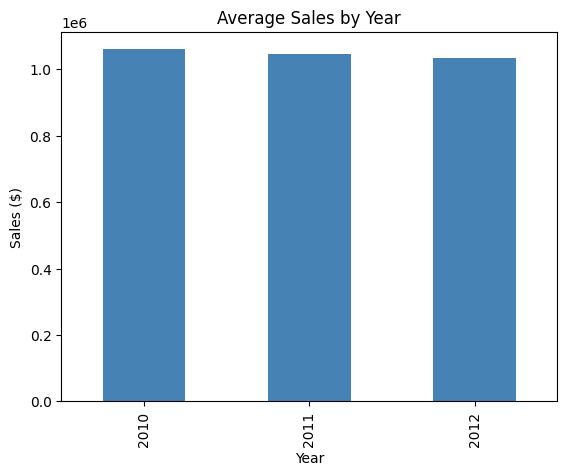

In [ ]:
df.groupby("Year")["Weekly_Sales"].mean().plot(kind="bar", color="steelblue")
plt.title("Average Sales by Year")
plt.ylabel("Sales ($)")
plt.show()

# تأثير الأعياد


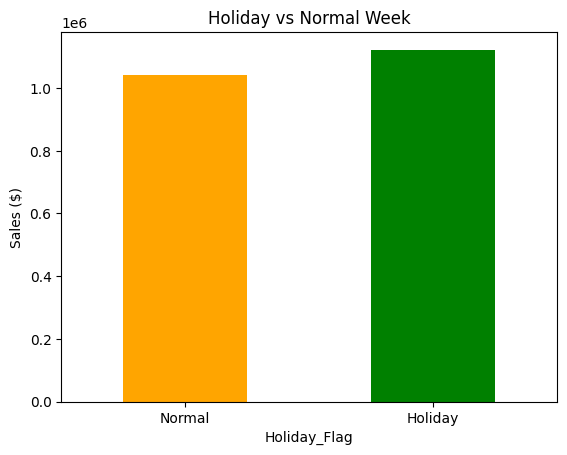

In [ ]:
df.groupby("Holiday_Flag")["Weekly_Sales"].mean().plot(kind="bar", color=["orange","green"])
plt.title("Holiday vs Normal Week")
plt.xticks([0,1], ["Normal","Holiday"], rotation=0)
plt.ylabel("Sales ($)")
plt.show()

#  أفضل المتاجر


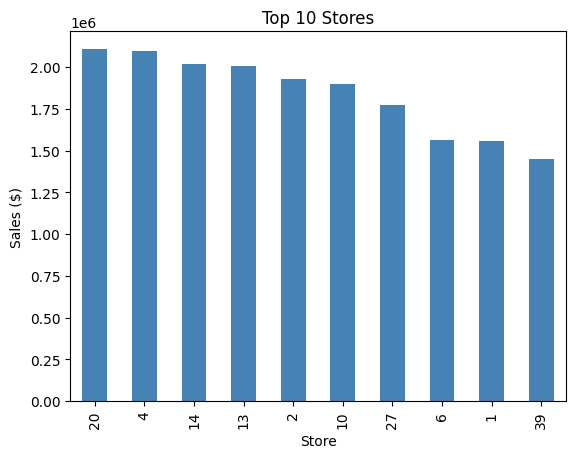

In [ ]:
df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False).head(10).plot(kind="bar", color="steelblue")
plt.title("Top 10 Stores")
plt.ylabel("Sales ($)")
plt.show()

# المبيعات الشهرية

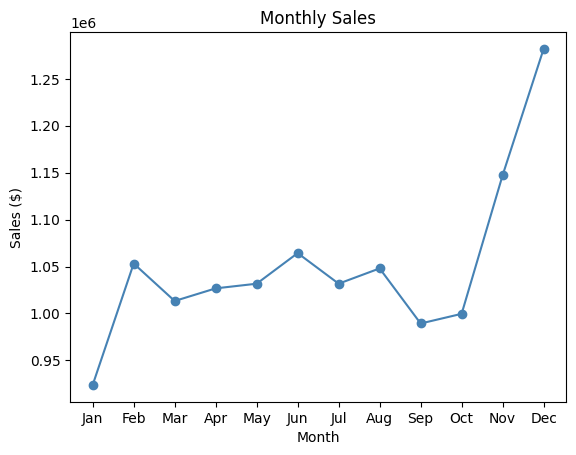

In [ ]:
df.groupby("Month")["Weekly_Sales"].mean().plot(kind="line", marker="o", color="steelblue")
plt.title("Monthly Sales")
plt.ylabel("Sales ($)")
plt.xticks(range(1,13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.show()

# علاقة المتغيرات ببعض


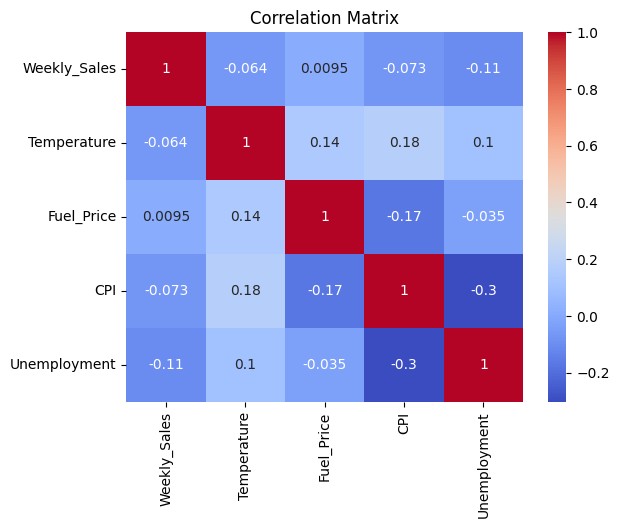

In [ ]:
corr = df[["Weekly_Sales","Temperature","Fuel_Price","CPI","Unemployment"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#  تأثير درجة الحرارة على المبيعات

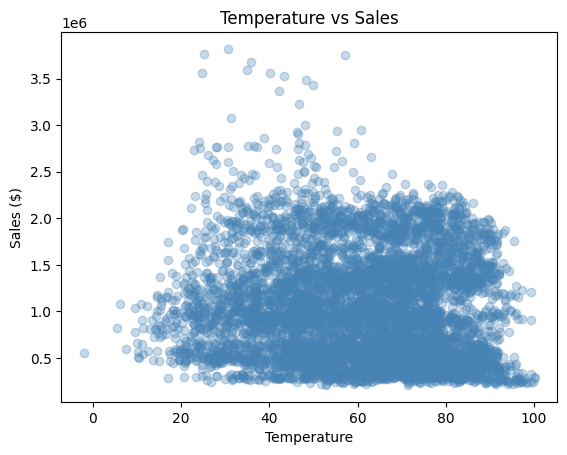

In [ ]:
plt.scatter(df["Temperature"], df["Weekly_Sales"], alpha=0.3, color="steelblue")
plt.title("Temperature vs Sales")
plt.xlabel("Temperature")
plt.ylabel("Sales ($)")
plt.show()